<a href="https://colab.research.google.com/github/lasyaa417/MGT-3078-Index-Arbitrage-Simulation/blob/main/Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/lasyaa417/MGT-3078-Index-Arbitrage-Simulation.git
%cd MGT-3078-Index-Arbitrage-Simulation
!ls

Cloning into 'MGT-3078-Index-Arbitrage-Simulation'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 58 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 21.63 MiB | 6.25 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/MGT-3078-Index-Arbitrage-Simulation
dow_10_factors_2009.csv		 dow_factor_inputs_2009_2016.csv
dow_10_factors_2010.csv		 dow_factor_inputs_2020_2025.csv
dow_10_factors_2011.csv		 icircalculations.ipynb
dow_10_factors_2012.csv		 README.md
dow_10_factors_2013.csv		 stat_arb_updated.ipynb
dow_10_factors_2014.csv		 yearly_composite_zscores_dynamic_factors
dow_10_factors_2015.csv		 yearly_composite_zscores_fixed_factors
dow_10_factors_2016.csv		 yearly_icir_results
dow_10_factors_2020_to_2025.csv


Preparing 2020-2025 Data and Calculating all Factors

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import statsmodels.api as sm
from scipy import stats
import matplotlib.dates as mdates

In [3]:
df_factor_input = pd.read_csv('/content/MGT-3078-Index-Arbitrage-Simulation/dow_factor_inputs_2020_2025.csv', index_col=0)

#Chaikin oscillator
money_flow_mult = ((df_factor_input['Close'] - df_factor_input['Low']) - (df_factor_input['High'] - df_factor_input['Close']))/(df_factor_input['High'] - df_factor_input['Low'])
money_flow_vol = money_flow_mult * df_factor_input['Volume']
df_factor_input['mf_vol'] = money_flow_vol
df_factor_input['ADL'] = df_factor_input.groupby('symbol')['mf_vol'].cumsum()
adl_groups = df_factor_input.groupby('symbol')['ADL']
ema_3 = adl_groups.transform(lambda x: x.ewm(span=3, adjust=False).mean())
ema_10 = adl_groups.transform(lambda x: x.ewm(span=10, adjust=False).mean())
df_factor_input['Chaikin_Oscillator'] = -(ema_3 - ema_10) #negative correlation

#Ma_20
grouped_close = df_factor_input.groupby('symbol')['Close']
df_factor_input['ma20'] = grouped_close.transform(lambda x: x.rolling(window=20).mean())
df_factor_input['std20'] = grouped_close.transform(lambda x: x.rolling(window=20).std())
df_factor_input['ZScore_MA20'] = (df_factor_input['Close'] - df_factor_input['ma20']) / df_factor_input['std20']

#Mom_12M_Refined
one_year_ago = 252
one_month_ago = 21
df_factor_input['Mom_12M_Refined'] = df_factor_input.groupby('symbol')['Close'].transform(
    lambda x: (x.shift(one_month_ago) / x.shift(one_year_ago)) - 1
)

#some of these look at past data, so we have to clip the first few days
df_factors_final = df_factor_input.dropna(subset=['Chaikin_Oscillator', 'ZScore_MA20', 'Mom_12M_Refined'])

#and I only want to focus on the symbol, date, chaikin osc, zscore_MA20, and Mom_12M
cols_to_keep = ['symbol', 'Chaikin_Oscillator', 'ZScore_MA20', 'Mom_12M_Refined']
df_factors = df_factors_final[cols_to_keep].copy()

#summing factors to compute zscore
#ok, but need to normalize first
raw_factors = ['Chaikin_Oscillator', 'ZScore_MA20', 'Mom_12M_Refined']
for f in raw_factors:
  df_factors[f'norm_{f}'] = df_factors.groupby(level=0)[f].transform(
      lambda x: (x - x.mean()) / x.std()
  )

df_factors['total'] = (df_factors['norm_Chaikin_Oscillator'] + df_factors['norm_ZScore_MA20'] + df_factors['norm_Mom_12M_Refined'])/3
df_factors['final_z'] = df_factors.groupby(level=0)['total'].transform(lambda x: (x - x.mean()) / x.std()) #standardizing
df_factors

,symbol,Chaikin_Oscillator,ZScore_MA20,Mom_12M_Refined,norm_Chaikin_Oscillator,norm_ZScore_MA20,norm_Mom_12M_Refined,total,final_z
date,,,,,,,,,
2019-01-03,AAPL,1.080424e+08,-2.147671,0.036689,2.724929,-1.886625,-0.094072,0.248077,0.675530
2019-01-03,AMGN,1.078183e+06,-0.315402,0.176554,-0.229214,0.670432,0.607234,0.349484,0.951667
2019-01-03,AMZN,-1.415345e+07,-0.441319,0.421493,-0.649882,0.494706,1.835404,0.560076,1.525122
2019-01-03,AXP,2.373220e+06,-1.030747,0.134728,-0.193447,-0.327881,0.397513,-0.041272,-0.112385
2019-01-03,BA,3.362129e+05,-0.878177,0.168171,-0.249706,-0.114958,0.565204,0.066847,0.182028
...,...,...,...,...,...,...,...,...,...
2025-12-31,UTX,5.573889e+05,0.762848,0.439637,0.007710,0.931381,1.046447,0.661846,1.286615
2025-12-31,V,-1.591406e+05,0.671988,0.036810,-0.030131,0.830892,-0.326872,0.157963,0.307077
2025-12-31,VZ,1.282270e+07,0.323425,0.020541,0.655447,0.445392,-0.382338,0.239500,0.465584


Simulation


,Date,Daily_Return,Portfolio_Value
0,2019-01-03,-0.000401,100000.000000
1,2019-01-04,-0.000850,99959.940974
2,2019-01-07,0.024404,99874.984449
3,2019-01-08,0.001330,102312.303186
4,2019-01-09,0.000806,102448.358441


Final portfolio value: $220654.41


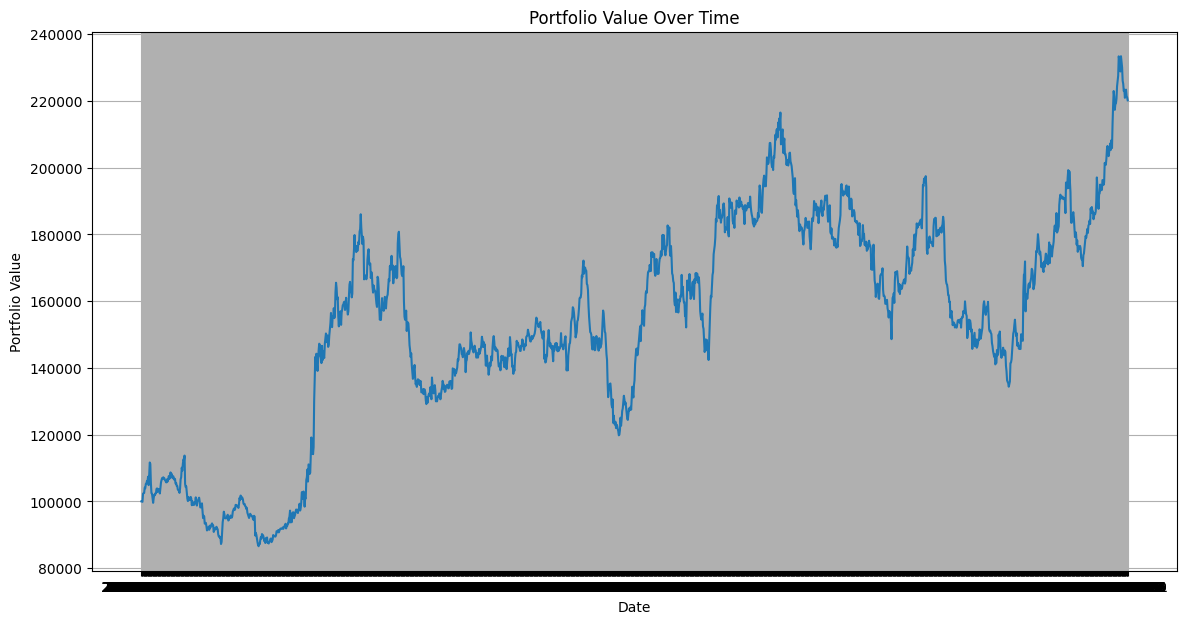

In [4]:
CAPITAL = 100000

# Calculate next_day_return on df_factor_input
df_factor_input['next_day_return'] = df_factor_input.groupby('symbol')['Close'].pct_change().shift(-1)

# Ensure df_factors has the next_day_return. We will merge it based on index (date) and 'symbol'
# Reset index of df_factors to merge 'date' and 'symbol' as columns
df_factors_temp = df_factors.reset_index()

# Select relevant columns from df_factor_input for merging
returns_to_merge = df_factor_input[['symbol', 'next_day_return']].reset_index()

# Merge next_day_return into df_factors_temp
df_factors_with_returns = pd.merge(
    df_factors_temp,
    returns_to_merge,
    on=['date', 'symbol'],
    how='left'
)

# Set the index back to 'date' and 'symbol'
df_factors_with_returns = df_factors_with_returns.set_index(['date', 'symbol'])


# calculating threshold for each date (using df_factors_with_returns now)
df_factors_with_returns['daily_upper'] = df_factors_with_returns.groupby(level=0)['total'].transform(
    lambda x: x.quantile(0.95)
)

df_factors_with_returns['daily_lower'] = df_factors_with_returns.groupby(level=0)['total'].transform(
    lambda x: x.quantile(0.05)
)

# get the unique number of trading days
trading_days = df_factors_with_returns.index.get_level_values('date').unique().sort_values()

# could be longed or shorted
df_factors_with_returns['is_long'] = df_factors_with_returns['total'] >= df_factors_with_returns['daily_upper']
df_factors_with_returns['is_short'] = df_factors_with_returns['total'] <= df_factors_with_returns['daily_lower']

daily_portfolio_returns = []
portfolio_values = [CAPITAL]

# go through each day
for date in trading_days:
    # Get all stocks for today
    day_df = df_factors_with_returns.loc[date].dropna(subset=['next_day_return']) # Drop rows where next_day_return is NaN

    # Check how many long and short candidates we have
    num_longs = day_df['is_long'].sum()
    num_shorts = day_df['is_short'].sum()

    # number we will actually short and long
    n = min(num_longs, num_shorts)

    daily_ret = 0 # Initialize daily return for the day

    if n > 0:
      long_picks = day_df[day_df['is_long']].sort_values('final_z', ascending=False).head(n)
      short_picks = day_df[day_df['is_short']].sort_values('final_z', ascending=True).head(n)

      avg_long_ret = long_picks['next_day_return'].mean()
      avg_short_ret = short_picks['next_day_return'].mean()

      # Long-short strategy: long the top N, short the bottom N
      daily_ret = avg_long_ret - avg_short_ret

    daily_portfolio_returns.append(daily_ret)
    CAPITAL *= (1 + daily_ret)
    portfolio_values.append(CAPITAL)

# Create a DataFrame for simulation results
simulation_results = pd.DataFrame({
    'Date': trading_days,
    'Daily_Return': daily_portfolio_returns
})

simulation_results['Portfolio_Value'] = [portfolio_values[i] for i in range(len(simulation_results))]

# Display the first few results and the final portfolio value
display(simulation_results.head())
print(f"Final portfolio value: ${CAPITAL:.2f}")

# Plot the portfolio value over time
plt.figure(figsize=(14, 7))
plt.plot(simulation_results['Date'], simulation_results['Portfolio_Value'])
plt.title('Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.show()

In [5]:
portfolio_details = []

for date in trading_days:
    day_df = df_factors_with_returns.loc[date].dropna(subset=['next_day_return'])

    num_longs = day_df['is_long'].sum()
    num_shorts = day_df['is_short'].sum()

    n = min(num_longs, num_shorts)

    if n > 0:
        long_picks = day_df[day_df['is_long']].sort_values('final_z', ascending=False).head(n)
        short_picks = day_df[day_df['is_short']].sort_values('final_z', ascending=True).head(n)

        for symbol, row in long_picks.iterrows():
            portfolio_details.append({
                'Date': date,
                'Symbol': symbol,
                'Position': 'Long',
                'Trade_Return': row['next_day_return'],
                'Z_Score': row['final_z']
            })

        for symbol, row in short_picks.iterrows():
            portfolio_details.append({
                'Date': date,
                'Symbol': symbol,
                'Position': 'Short',
                'Trade_Return': row['next_day_return'],
                'Z_Score': row['final_z']
            })

df_portfolio_details = pd.DataFrame(portfolio_details)
display(df_portfolio_details.head(10))
print(f"Total unique days in portfolio details: {df_portfolio_details['Date'].nunique()}")
print(f"Total trades recorded: {len(df_portfolio_details)}")

,Date,Symbol,Position,Trade_Return,Z_Score
0,2019-01-03,NVDA,Long,-0.027977,2.752546
1,2019-01-03,AMZN,Long,-0.023516,1.525122
2,2019-01-03,MMM,Short,-0.020505,-1.656964
3,2019-01-03,RTX,Short,-0.030186,-1.388543
4,2019-01-04,NVDA,Long,0.022835,2.377639
5,2019-01-04,CRM,Long,0.045045,1.814691
6,2019-01-04,RTX,Short,0.026499,-1.722779
7,2019-01-04,UTX,Short,0.043081,-1.722779
8,2019-01-07,CRM,Long,0.006757,1.968028
9,2019-01-07,NKE,Long,0.052941,1.447679


Total unique days in portfolio details: 1759
Total trades recorded: 7040


In [6]:
df_portfolio_details.to_csv("portfolio_trades.csv", index=False)

Identifying Long and Short Opportunities: For each trading day, the code identifies stocks that are considered 'long' candidates (those with a total factor score above the 95th percentile for that day, indicated by is_long = True) and 'short' candidates (those with a total factor score below the 5th percentile, indicated by is_short = True).

Selecting Top/Bottom n Stocks: The variable n is determined as the minimum number of available long and short candidates for that day. This ensures an equal number of stocks for the long and short sides of the portfolio. Then, the top n stocks with the highest final_z score among long candidates are selected for the 'long' side, and the top n stocks with the lowest final_z score among short candidates are selected for the 'short' side.

Calculating Average Returns: For the selected long picks, the average of their next_day_return is calculated (avg_long_ret). Similarly, for the selected short picks, the average of their next_day_return is calculated (avg_short_ret).

Portfolio Daily Return (daily_ret): The daily return for the portfolio (daily_ret) is calculated as the difference between the average long return and the average short return (avg_long_ret - avg_short_ret). This represents a classic dollar-neutral long-short strategy, where you profit from the spread between the long and short positions.

Updating Portfolio Value: The CAPITAL (initial portfolio value) is updated daily by multiplying it with (1 + daily_ret). This new CAPITAL value is then stored in the portfolio_values list, showing how the total portfolio value changes over time.

simulation_results DataFrame: Finally, the simulation_results DataFrame is constructed. It contains:

Date: The trading days of the simulation.
Daily_Return: The daily_ret calculated for each day.
Portfolio_Value: The cumulative value of the portfolio at the end of each day, based on the daily_ret.

In [7]:
df_portfolio_details['Adj_Return'] = np.where(
    df_portfolio_details['Position'] == 'Long',
    df_portfolio_details['Trade_Return'],
    -df_portfolio_details['Trade_Return']
)

daily_returns = df_portfolio_details.groupby('Date')['Adj_Return'].mean()

# 2. Cumulative Returns
cum_returns = (1 + daily_returns).cumprod()

# 3. Sharpe Ratio (assuming Rf = 0 for simplicity)
sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)

# 4. Max Drawdown
rolling_max = cum_returns.cummax()
drawdown = (cum_returns - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

Sharpe Ratio: 0.57
Max Drawdown: -20.30%


In [8]:
# Ensure Date is in datetime format
df_portfolio_details['Date'] = pd.to_datetime(df_portfolio_details['Date'])

# 1. Create the Strategy Return column if not already there
df_portfolio_details['Strategy_Ret'] = np.where(
    df_portfolio_details['Position'] == 'Long',
    df_portfolio_details['Trade_Return'],
    -df_portfolio_details['Trade_Return']
)

# 2. Get daily portfolio returns
daily_returns = df_portfolio_details.groupby('Date')['Strategy_Ret'].mean()

# 3. Create a DataFrame for annual metrics
annual_stats = []

# Group by the year of the index (Date)
for year, group in daily_returns.groupby(daily_returns.index.year):
    # 1. Annualized Volatility
    # Daily standard deviation * sqrt(252)
    vol = group.std() * np.sqrt(252)

    # 2. Annualized Sharpe Ratio
    # Mean daily return / daily std * sqrt(252)
    sharpe = (group.mean() / group.std()) * np.sqrt(252) if group.std() != 0 else 0

    # 3. Max Drawdown for that specific year
    cum_ret = (1 + group).cumprod()
    peaks = cum_ret.cummax()
    mdd = ((cum_ret - peaks) / peaks).min()

    # 4. Total return for the year
    total_ret = cum_ret.iloc[-1] - 1

    annual_stats.append({
        'Year': year,
        'Annual_Return': total_ret,
        'Annualized_Volatility': vol,
        'Annualized_Sharpe': sharpe,
        'Max_Drawdown': mdd
    })

# Convert to DataFrame for easy viewing
df_annual_metrics = pd.DataFrame(annual_stats)
display(df_annual_metrics.style.format({
    'Annual_Return': '{:.2%}',
    'Annualized_Volatility': '{:.2%}',
    'Annualized_Sharpe': '{:.2f}',
    'Max_Drawdown': '{:.2%}'
}))

df_annual_report = pd.DataFrame(annual_stats)
display(df_annual_report)

,Year,Annual_Return,Annualized_Volatility,Annualized_Sharpe,Max_Drawdown
0,2019,-3.66%,9.82%,-0.33,-12.50%
1,2020,22.21%,16.49%,1.29,-15.33%
2,2021,6.30%,10.06%,0.66,-4.38%
3,2022,-0.42%,13.86%,0.04,-16.38%
4,2023,16.48%,11.59%,1.38,-9.84%
5,2024,-8.69%,12.42%,-0.67,-13.82%
6,2025,18.50%,13.09%,1.37,-7.43%


,Year,Annual_Return,Annualized_Volatility,Annualized_Sharpe,Max_Drawdown
0,2019,-0.036608,0.098197,-0.332101,-0.125017
1,2020,0.222086,0.164925,1.293355,-0.153267
2,2021,0.062966,0.100592,0.657161,-0.043832
3,2022,-0.004234,0.138576,0.038299,-0.163825
4,2023,0.164830,0.115914,1.384846,-0.098361
5,2024,-0.086873,0.124159,-0.669646,-0.138225
6,2025,0.185014,0.130913,1.372560,-0.074299


[*********************100%***********************]  2 of 2 completed


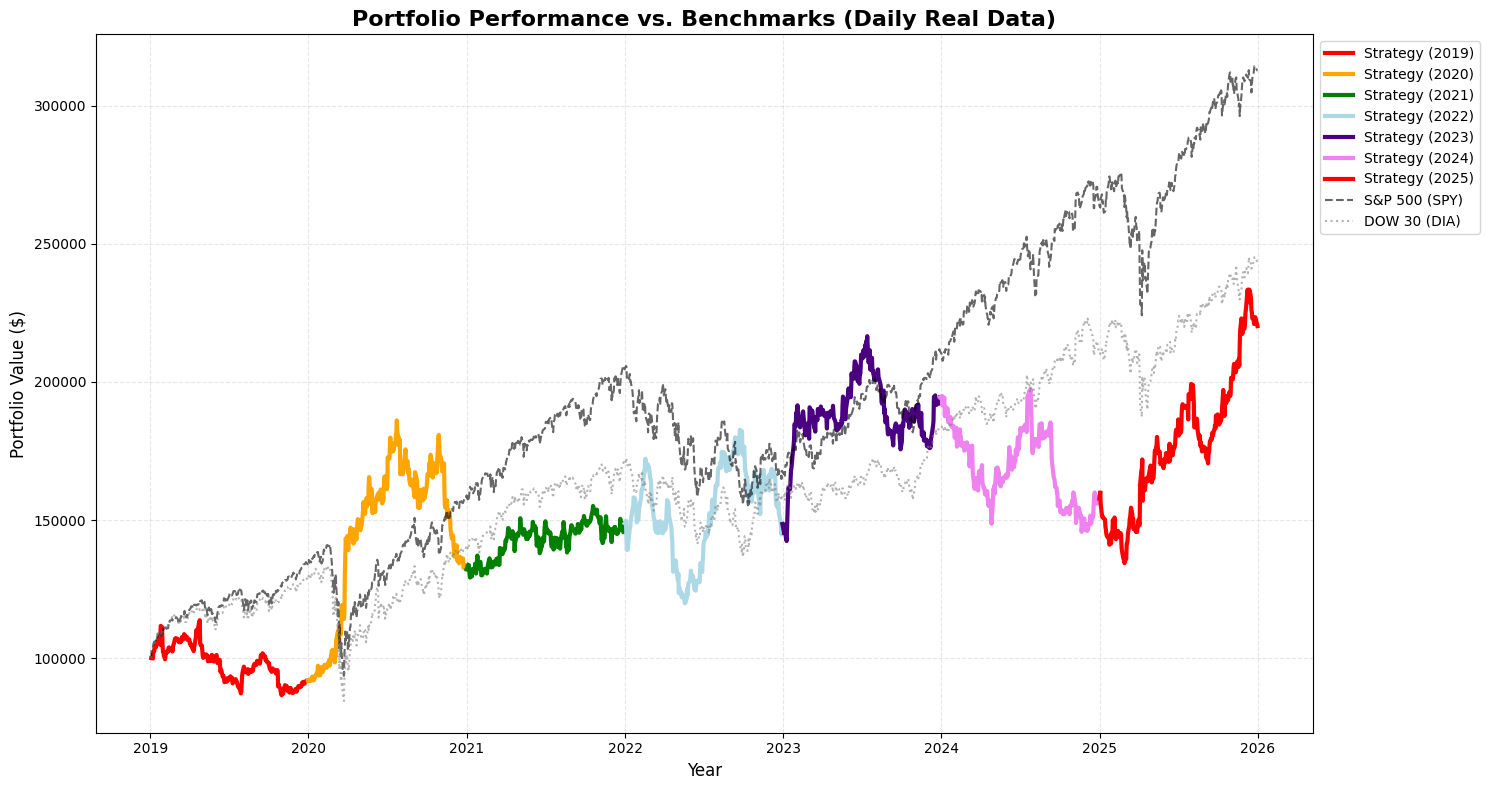

--- OVERALL INCEPTION-TO-DATE PERFORMANCE ---


,Metric,Portfolio,S&P 500 (SPY),DOW 30 (DIA)
0,Cumulative Return,120.20%,212.81%,143.48%
1,Annualized Return,11.95%,17.71%,13.57%



--- ANNUALIZED PERFORMANCE BY YEAR ---


,Year,Portfolio (Ann),S&P 500 (Ann),DOW 30 (Ann)
0,2019,-8.25%,34.65%,28.89%
1,2020,43.95%,17.30%,8.28%
2,2021,11.50%,30.92%,22.50%
3,2022,-0.63%,-18.84%,-7.70%
4,2023,34.27%,27.15%,16.31%
5,2024,-19.04%,25.69%,14.81%
6,2025,38.06%,19.02%,16.00%


In [10]:
# 1. Convert Date to datetime to avoid AttributeErrors
simulation_results['Date'] = pd.to_datetime(simulation_results['Date'])
start_date = simulation_results['Date'].min()
end_date = simulation_results['Date'].max()

# 2. Download Real Market Data (SPY and DIA)
# We set auto_adjust=False to ensure we can specifically grab 'Adj Close'
# OR we use 'Close' if it auto-adjusts. Let's be explicit:
bench_data = yf.download(['SPY', 'DIA'], start=start_date, end=end_date, auto_adjust=True)

# Handle MultiIndex columns for multiple tickers
# With auto_adjust=True, the data is under the 'Close' header
bench_closes = bench_data['Close']

# Calculate daily returns for benchmarks
bench_returns = bench_closes.pct_change().fillna(0)

# Align benchmark returns with simulation dates (handling weekends/holidays)
bench_returns = bench_returns.reindex(simulation_results['Date']).fillna(0)

# 3. Normalize to start at your initial CAPITAL
initial_cap = 100000
simulation_results['SPY_Value'] = initial_cap * (1 + bench_returns['SPY']).cumprod().values
simulation_results['DIA_Value'] = initial_cap * (1 + bench_returns['DIA']).cumprod().values
simulation_results['Year'] = simulation_results['Date'].dt.year

# 4. Plotting with Requested Colors: red, orange, green, lightblue, indigo, violet
plt.figure(figsize=(15, 8))

custom_colors = ['red', 'orange', 'green', 'lightblue', 'indigo', 'violet']
years = sorted(simulation_results['Year'].unique())

for i, year in enumerate(years):
    year_data = simulation_results[simulation_results['Year'] == year]
    color = custom_colors[i % len(custom_colors)] # Cycles if > 6 years

    # Plot segment for the year
    plt.plot(year_data['Date'], year_data['Portfolio_Value'],
             color=color, label=f"Strategy ({year})", linewidth=3)

    # Connect to the next year visually to ensure a continuous line
    if i < len(years) - 1:
        next_year_data = simulation_results[simulation_results['Year'] == years[i+1]]
        next_color = custom_colors[(i + 1) % len(custom_colors)]
        plt.plot([year_data['Date'].iloc[-1], next_year_data['Date'].iloc[0]],
                 [year_data['Portfolio_Value'].iloc[-1], next_year_data['Portfolio_Value'].iloc[0]],
                 color=next_color, linewidth=3)

# 5. Plot Benchmarks (Real Daily Data)
plt.plot(simulation_results['Date'], simulation_results['SPY_Value'],
         color='black', linestyle='--', alpha=0.6, label='S&P 500 (SPY)')
plt.plot(simulation_results['Date'], simulation_results['DIA_Value'],
         color='gray', linestyle=':', alpha=0.6, label='DOW 30 (DIA)')

# Format the plot
plt.title('Portfolio Performance vs. Benchmarks (Daily Real Data)', fontsize=16, fontweight='bold')
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# 6. Final Performance Summary Table
total_days = (end_date - start_date).days
years_count = total_days / 365.25

# Define the final values for calculation
strat_final = simulation_results['Portfolio_Value'].iloc[-1]
spy_final = simulation_results['SPY_Value'].iloc[-1]
dia_final = simulation_results['DIA_Value'].iloc[-1]

# 1. Overall ITD Summary (As you had it)
total_days_itd = (end_date - start_date).days
years_itd = total_days_itd / 365.25

perf_summary_itd = pd.DataFrame({
    'Metric': ['Cumulative Return', 'Annualized Return'],
    'Portfolio': [
        f"{(strat_final/initial_cap)-1:.2%}",
        f"{(strat_final/initial_cap)**(1/years_itd)-1:.2%}"
    ],
    'S&P 500 (SPY)': [
        f"{(spy_final/initial_cap)-1:.2%}",
        f"{(spy_final/initial_cap)**(1/years_itd)-1:.2%}"
    ],
    'DOW 30 (DIA)': [
        f"{(dia_final/initial_cap)-1:.2%}",
        f"{(dia_final/initial_cap)**(1/years_itd)-1:.2%}"
    ]
})

# 2. Year-by-Year Annualized Returns
annual_performance = []

for year, group in simulation_results.groupby('Year'):
    # Days in this specific period
    period_days = (group['Date'].max() - group['Date'].min()).days
    # Use 1 if the period is very short (prevents division by zero)
    year_frac = max(period_days, 1) / 365.25

    # Portfolio Annualized Return for the Year
    p_start = group['Portfolio_Value'].iloc[0]
    p_end = group['Portfolio_Value'].iloc[-1]
    p_ann = (p_end / p_start)**(1/year_frac) - 1 if year_frac > 0 else 0

    # S&P 500 Annualized Return for the Year
    s_start = group['SPY_Value'].iloc[0]
    s_end = group['SPY_Value'].iloc[-1]
    s_ann = (s_end / s_start)**(1/year_frac) - 1 if year_frac > 0 else 0

    # DOW 30 Annualized Return for the Year
    d_start = group['DIA_Value'].iloc[0]
    d_end = group['DIA_Value'].iloc[-1]
    d_ann = (d_end / d_start)**(1/year_frac) - 1 if year_frac > 0 else 0

    annual_performance.append({
        'Year': year,
        'Portfolio (Ann)': f"{p_ann:.2%}",
        'S&P 500 (Ann)': f"{s_ann:.2%}",
        'DOW 30 (Ann)': f"{d_ann:.2%}"
    })

df_annual_returns = pd.DataFrame(annual_performance)

print("--- OVERALL INCEPTION-TO-DATE PERFORMANCE ---")
display(perf_summary_itd)

print("\n--- ANNUALIZED PERFORMANCE BY YEAR ---")
display(df_annual_returns)